# ESoC 2026 — CLAAS: All 5 Channels Explorer

Plots all 5 channels for each run on the same time axis:
- **Sensor1** — microphone audio
- **VoltageSignal** — metal detector (spike = stone)
- **VehicleSpeed** — harvester speed
- **CutLength** — header cut length setting
- **Status** — header On/Off

> **Note on Status channel:** The README describes it as `boolean (1=on, 0=off)` but the actual data stores it as byte strings `b'On'` / `b'Off'` (dtype `|S3`). The README is incorrect on this point. We convert it to 1/0 for plotting.

In [1]:
from asammdf import MDF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_DIR = Path("data")
MF4_FILES = sorted(DATA_DIR.glob("*.mf4"))

# Verify Status channel dtype across all files
print("Status channel verification (README says boolean 1/0):")
print("-" * 55)
for f in MF4_FILES:
    mf = MDF(f)
    s = mf.get("Status")
    unique_vals = np.unique(s.samples)
    print(f"{f.name}")
    print(f"  dtype  : {s.samples.dtype}")
    print(f"  unique : {unique_vals}")
    print(f"  README says 1/0 — actual is byte strings: {s.samples.dtype == '|S3'}")
    print()

Status channel verification (README says boolean 1/0):
-------------------------------------------------------
Messung_2025-05-09_08-59-34.mf4
  dtype  : |S3
  unique : [b'Off' b'On']
  README says 1/0 — actual is byte strings: True

Messung_2025-05-14_16-02-23.mf4
  dtype  : |S3
  unique : [b'Off' b'On']
  README says 1/0 — actual is byte strings: True

Messung_2025-05-20_16-30-26.mf4
  dtype  : |S3
  unique : [b'Off' b'On']
  README says 1/0 — actual is byte strings: True

Messung_2025-10-01_09-42-16.mf4
  dtype  : |S3
  unique : [b'Off' b'On']
  README says 1/0 — actual is byte strings: True

Messung_2025-10-01_17-18-12.mf4
  dtype  : |S3
  unique : [b'Off' b'On']
  README says 1/0 — actual is byte strings: True



## Helper functions

In [2]:
def load_all_channels(path):
    mf = MDF(path)
    return {
        name: mf.get(name)
        for name in ["Sensor1", "VoltageSignal", "VehicleSpeed", "CutLength", "Status"]
    }

def status_to_binary(status_channel):
    """Convert b'On'/b'Off' byte strings → 1/0 integers for plotting."""
    return (status_channel.samples.astype(str) == 'On').astype(int)

def get_stone_spike_times(volt_channel, threshold_multiplier=5.0):
    """
    Find first onset of each voltage spike (stone detection event).
    Uses adaptive threshold: baseline median + N * std of first 5% of signal.
    """
    v = volt_channel.samples
    t = volt_channel.timestamps
    n_baseline = max(50, len(v) // 20)
    baseline = np.median(v[:n_baseline])
    noise = np.std(v[:n_baseline])
    threshold = baseline + threshold_multiplier * max(noise, 1.0)
    spike_mask = v > threshold
    edges = np.diff(spike_mask.astype(int))
    spike_onset_times = t[np.where(edges == 1)[0] + 1]
    # Deduplicate: merge spikes within 1 second of each other (same stone event)
    if len(spike_onset_times) == 0:
        return np.array([])
    merged = [spike_onset_times[0]]
    for st in spike_onset_times[1:]:
        if st - merged[-1] > 1.0:
            merged.append(st)
    return np.array(merged)

## All 5 channels — one plot per run

Reading the plot:
- **Green shading** = header is On (harvesting happening, stones possible)
- **Red dashed line** = metal detector fired (stone detected)
- When Status drops from 1→0 shortly after a red line, that confirms the header shut down due to stone detection

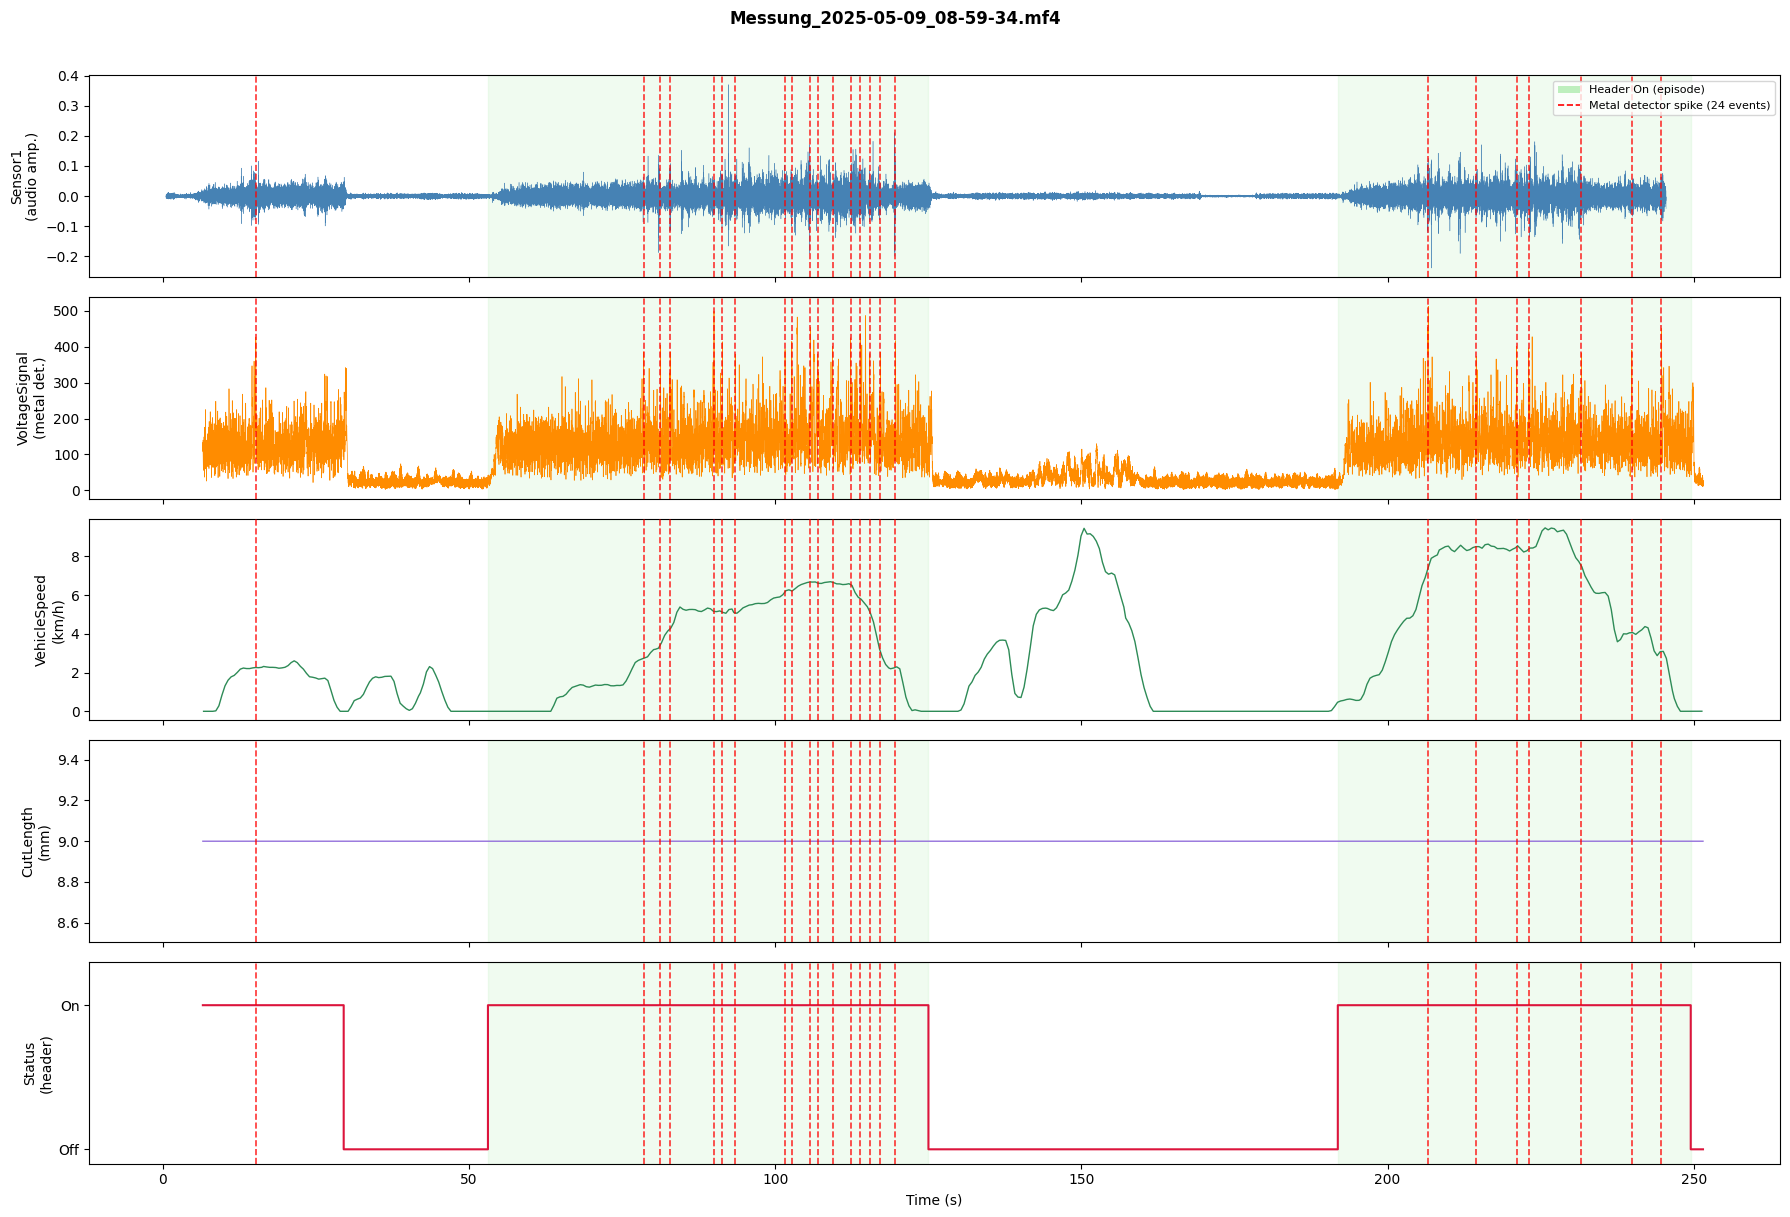

Episodes and stone events in Messung_2025-05-09_08-59-34.mf4:
  Episode 1  [53.1s → 125.0s]  duration=71.9s  → STONE at +25.43s into episode  (header shut down at 125.0s)
  Episode 2  [191.9s → 249.5s]  duration=57.6s  → STONE at +14.68s into episode  (header shut down at 249.5s)



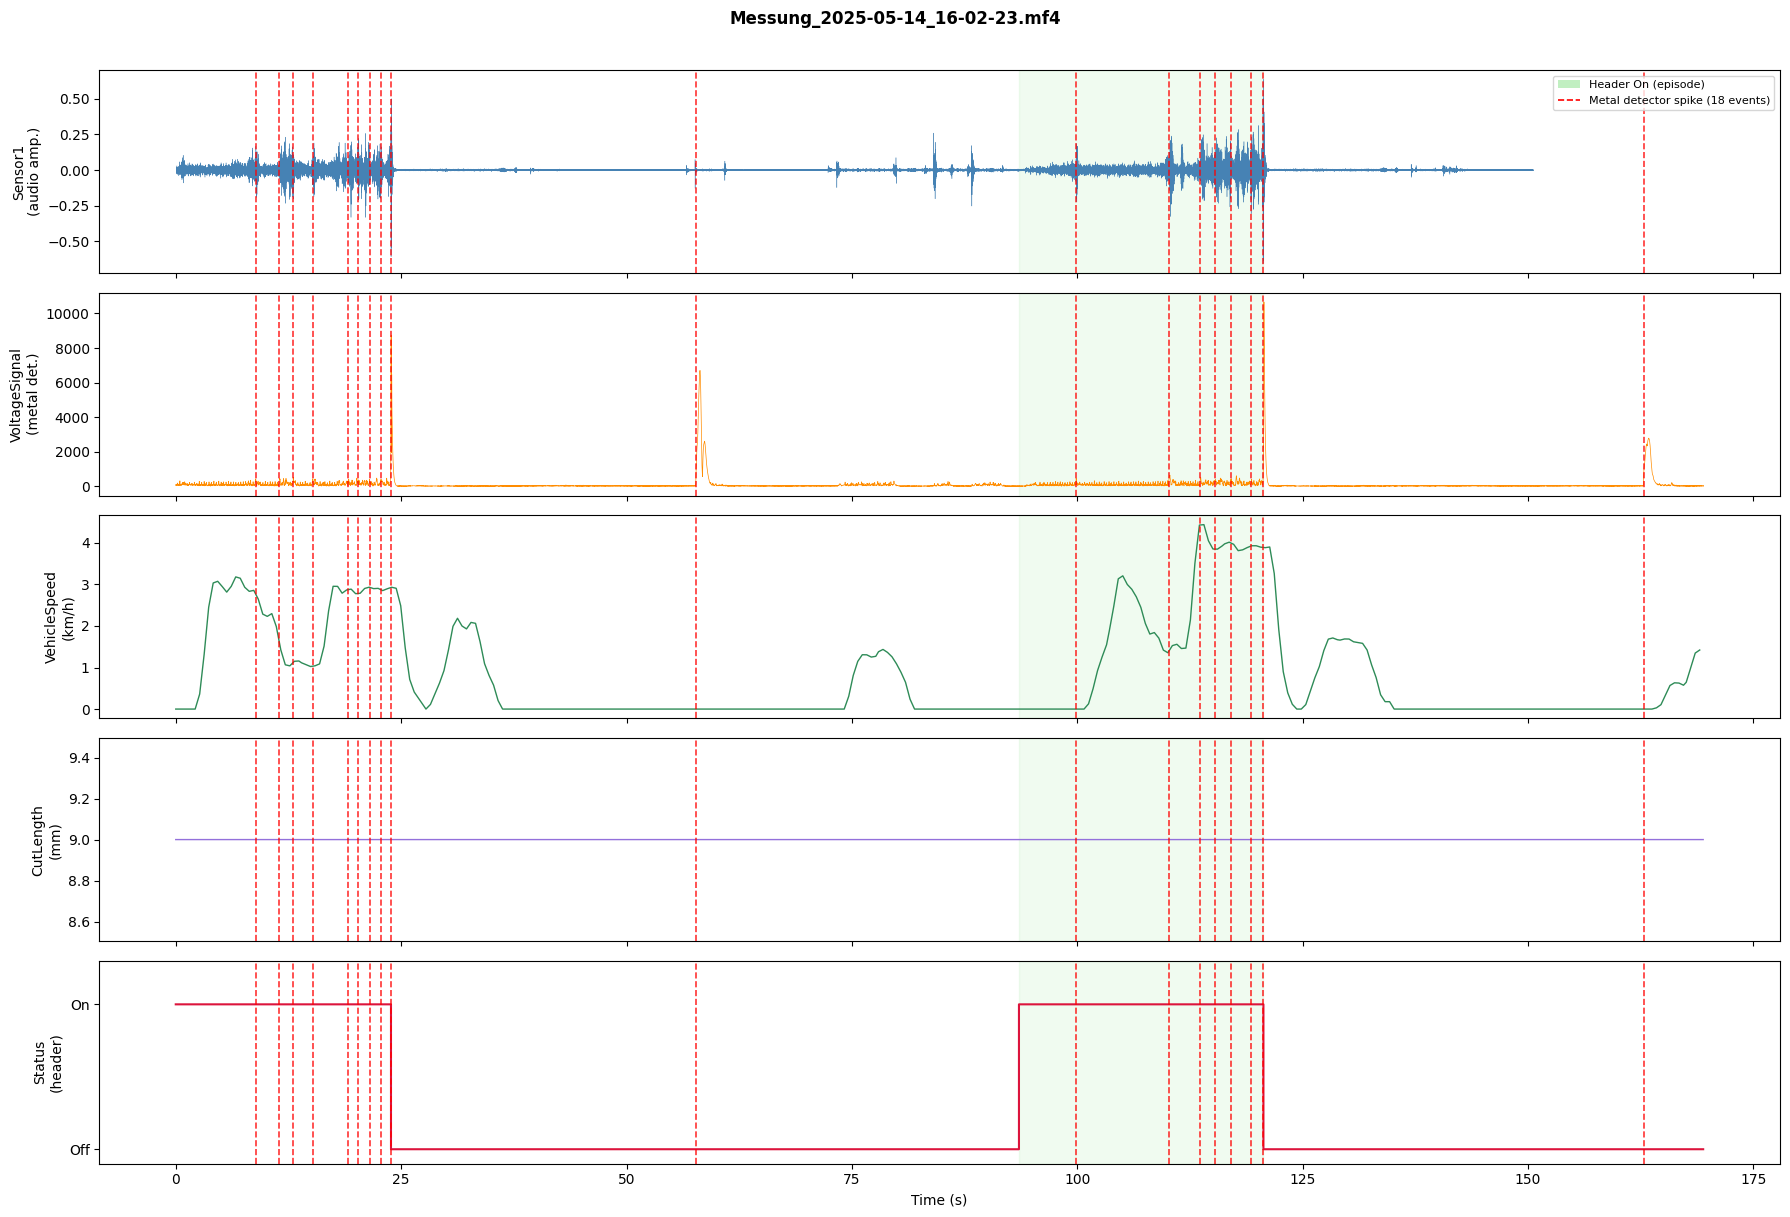

Episodes and stone events in Messung_2025-05-14_16-02-23.mf4:
  Episode 1  [93.5s → 120.6s]  duration=27.1s  → STONE at +6.33s into episode  (header shut down at 120.6s)



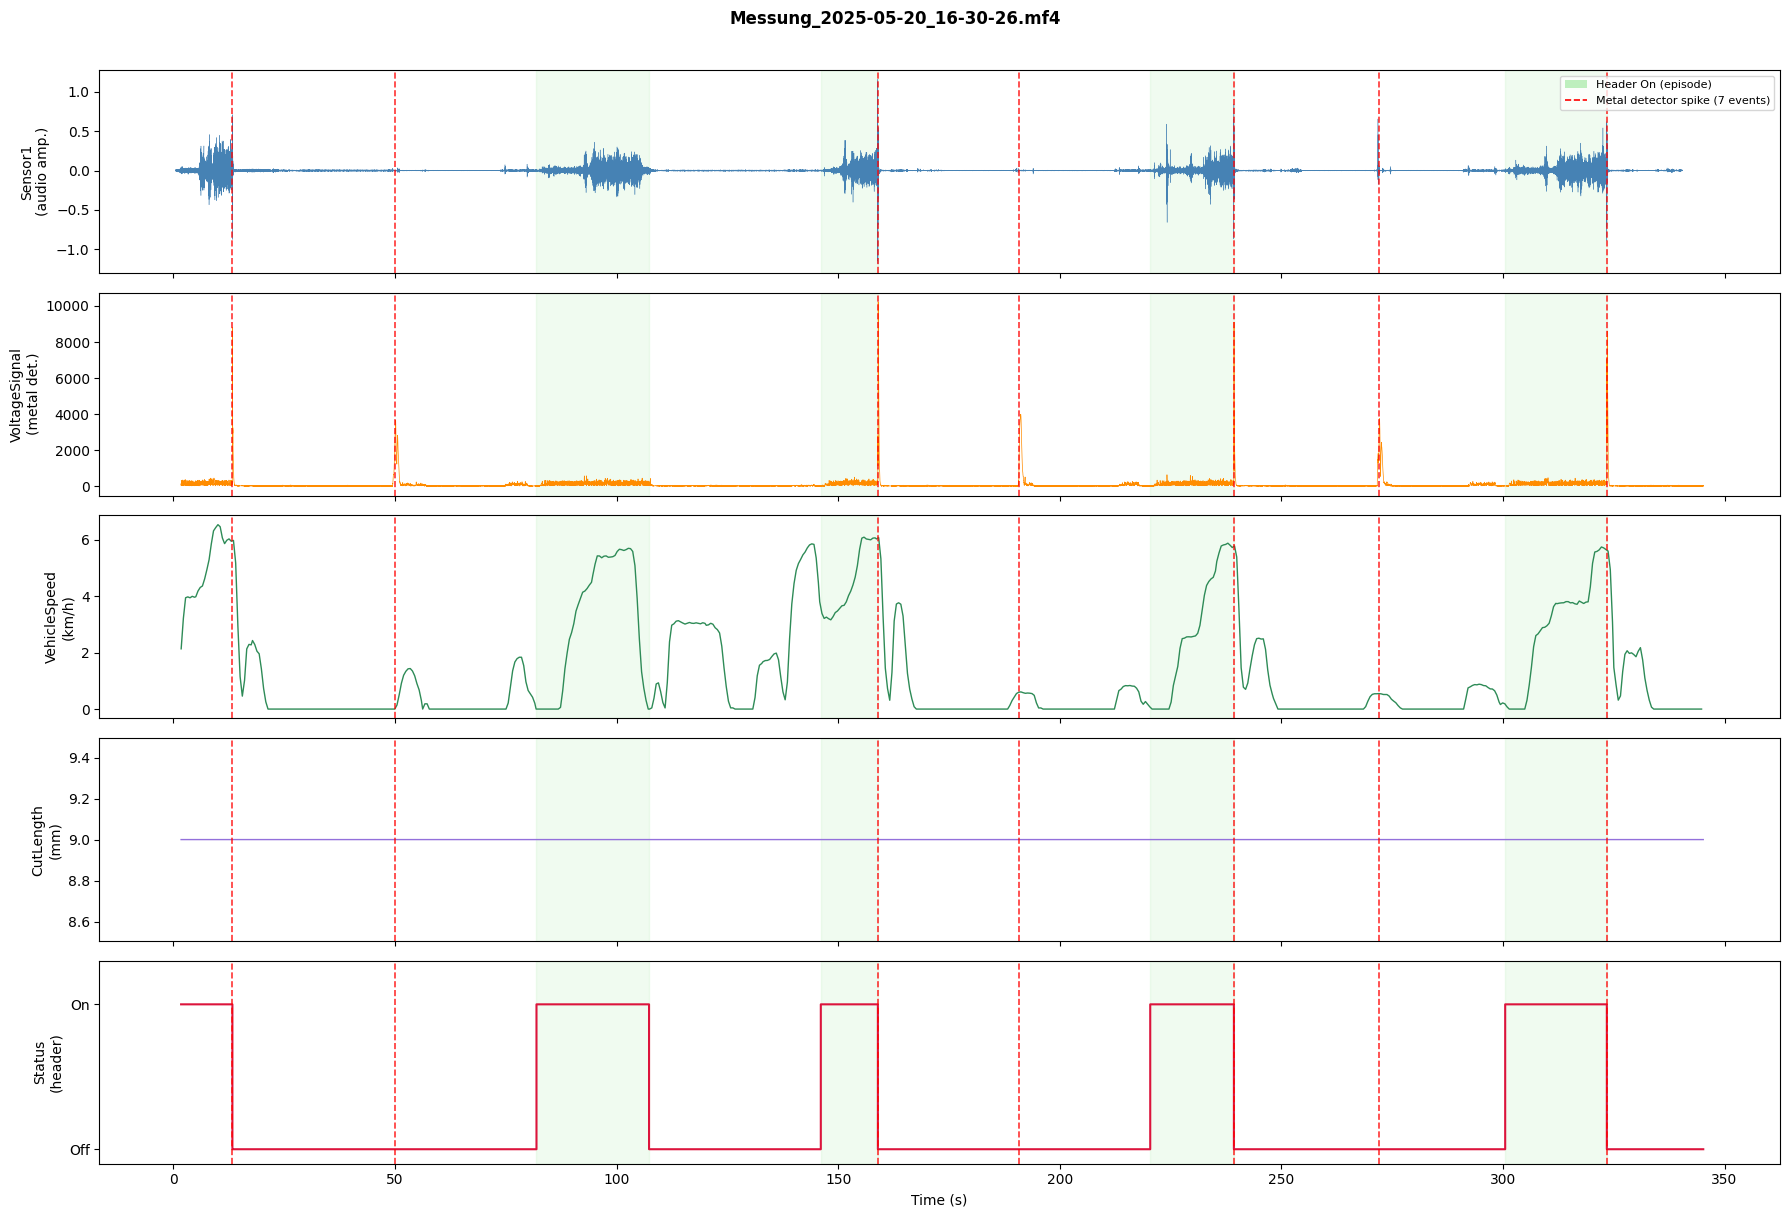

Episodes and stone events in Messung_2025-05-20_16-30-26.mf4:
  Episode 1  [81.9s → 107.3s]  duration=25.4s  → no spike
  Episode 2  [146.1s → 158.9s]  duration=12.9s  → no spike
  Episode 3  [220.4s → 239.3s]  duration=18.9s  → no spike
  Episode 4  [300.5s → 323.4s]  duration=22.9s  → STONE at +22.93s into episode  (header shut down at 323.4s)



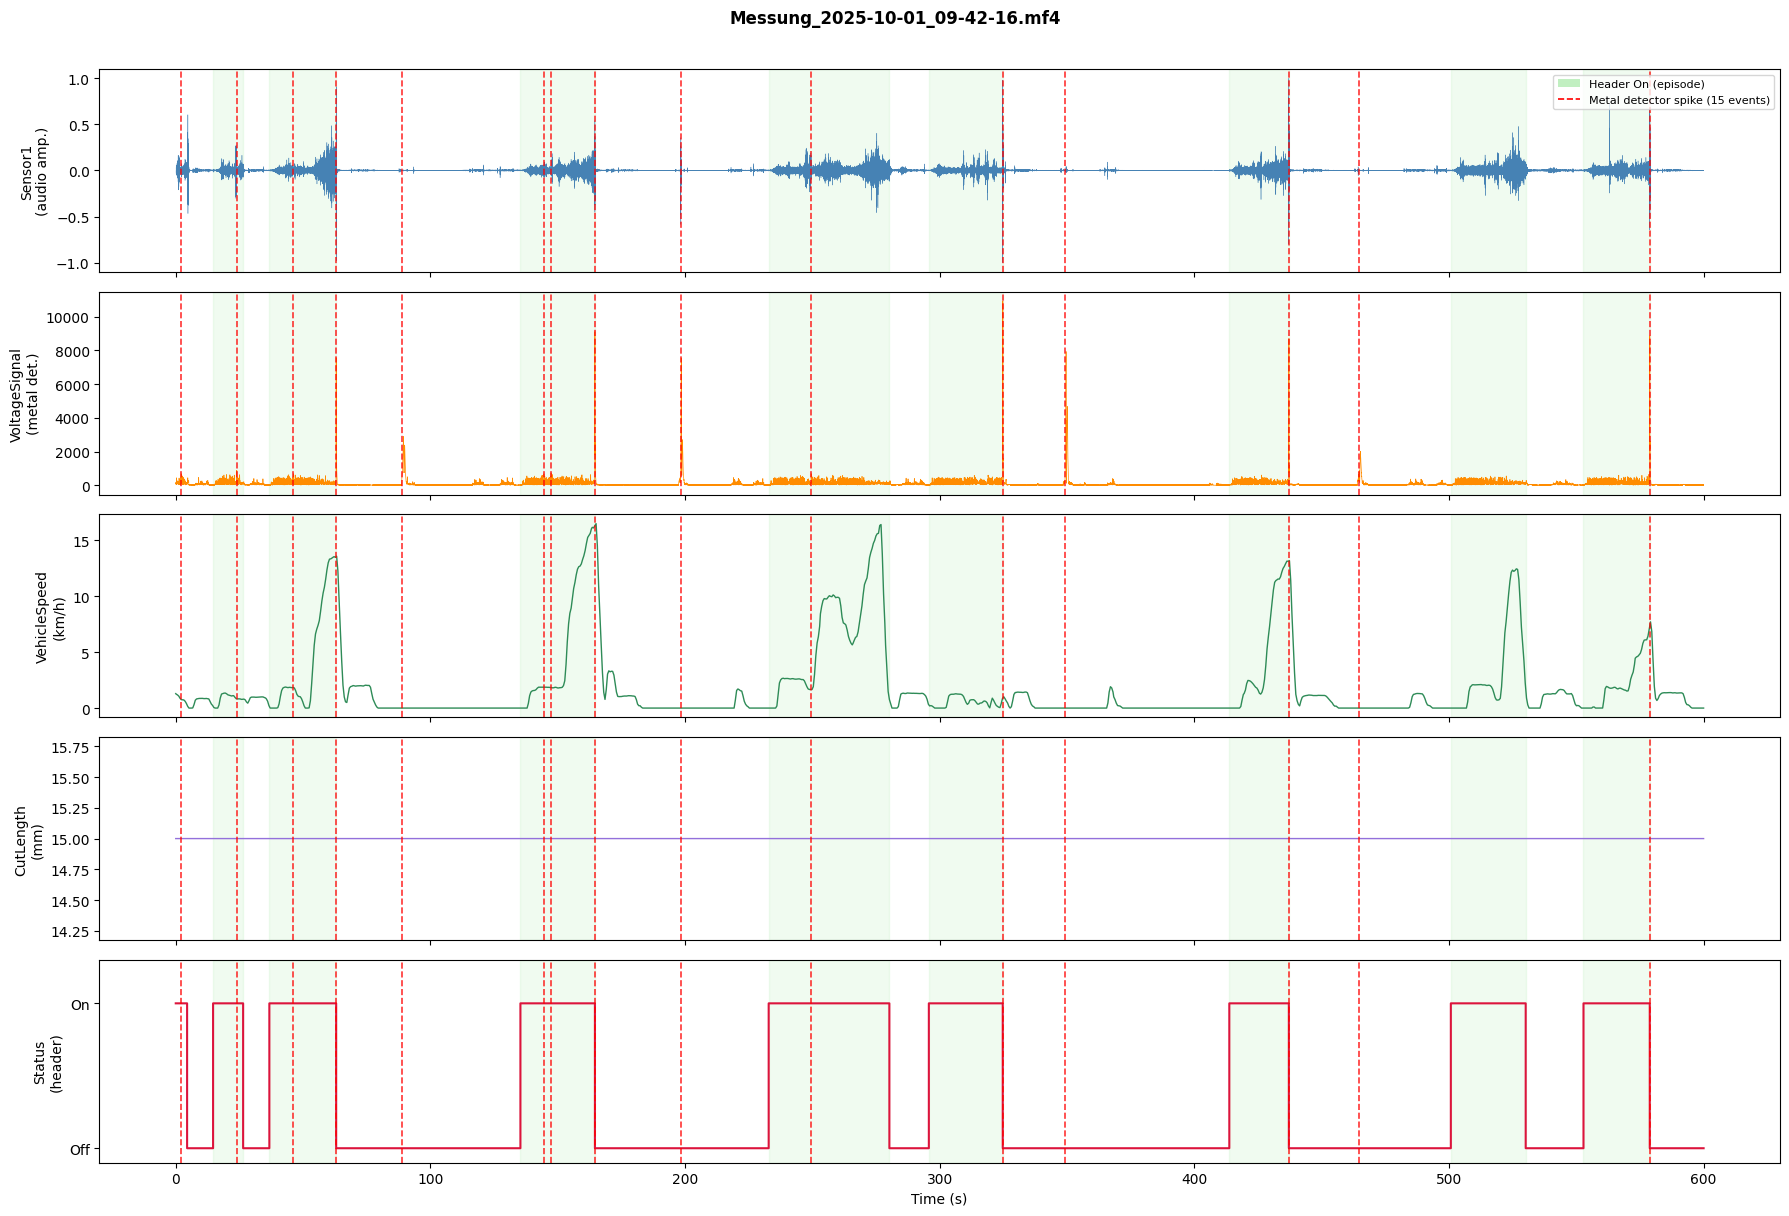

Episodes and stone events in Messung_2025-10-01_09-42-16.mf4:
  Episode 1  [14.7s → 26.5s]  duration=11.8s  → STONE at +9.27s into episode  (header shut down at 26.5s)
  Episode 2  [36.8s → 63.0s]  duration=26.2s  → STONE at +9.47s into episode  (header shut down at 63.0s)
  Episode 3  [135.4s → 164.6s]  duration=29.3s  → STONE at +9.23s into episode  (header shut down at 164.6s)
  Episode 4  [232.8s → 280.2s]  duration=47.4s  → STONE at +16.67s into episode  (header shut down at 280.2s)
  Episode 5  [295.7s → 324.8s]  duration=29.0s  → STONE at +28.94s into episode  (header shut down at 324.8s)
  Episode 6  [413.7s → 437.1s]  duration=23.4s  → STONE at +23.31s into episode  (header shut down at 437.1s)
  Episode 7  [500.7s → 530.1s]  duration=29.4s  → no spike
  Episode 8  [552.8s → 578.9s]  duration=26.0s  → STONE at +25.98s into episode  (header shut down at 578.9s)



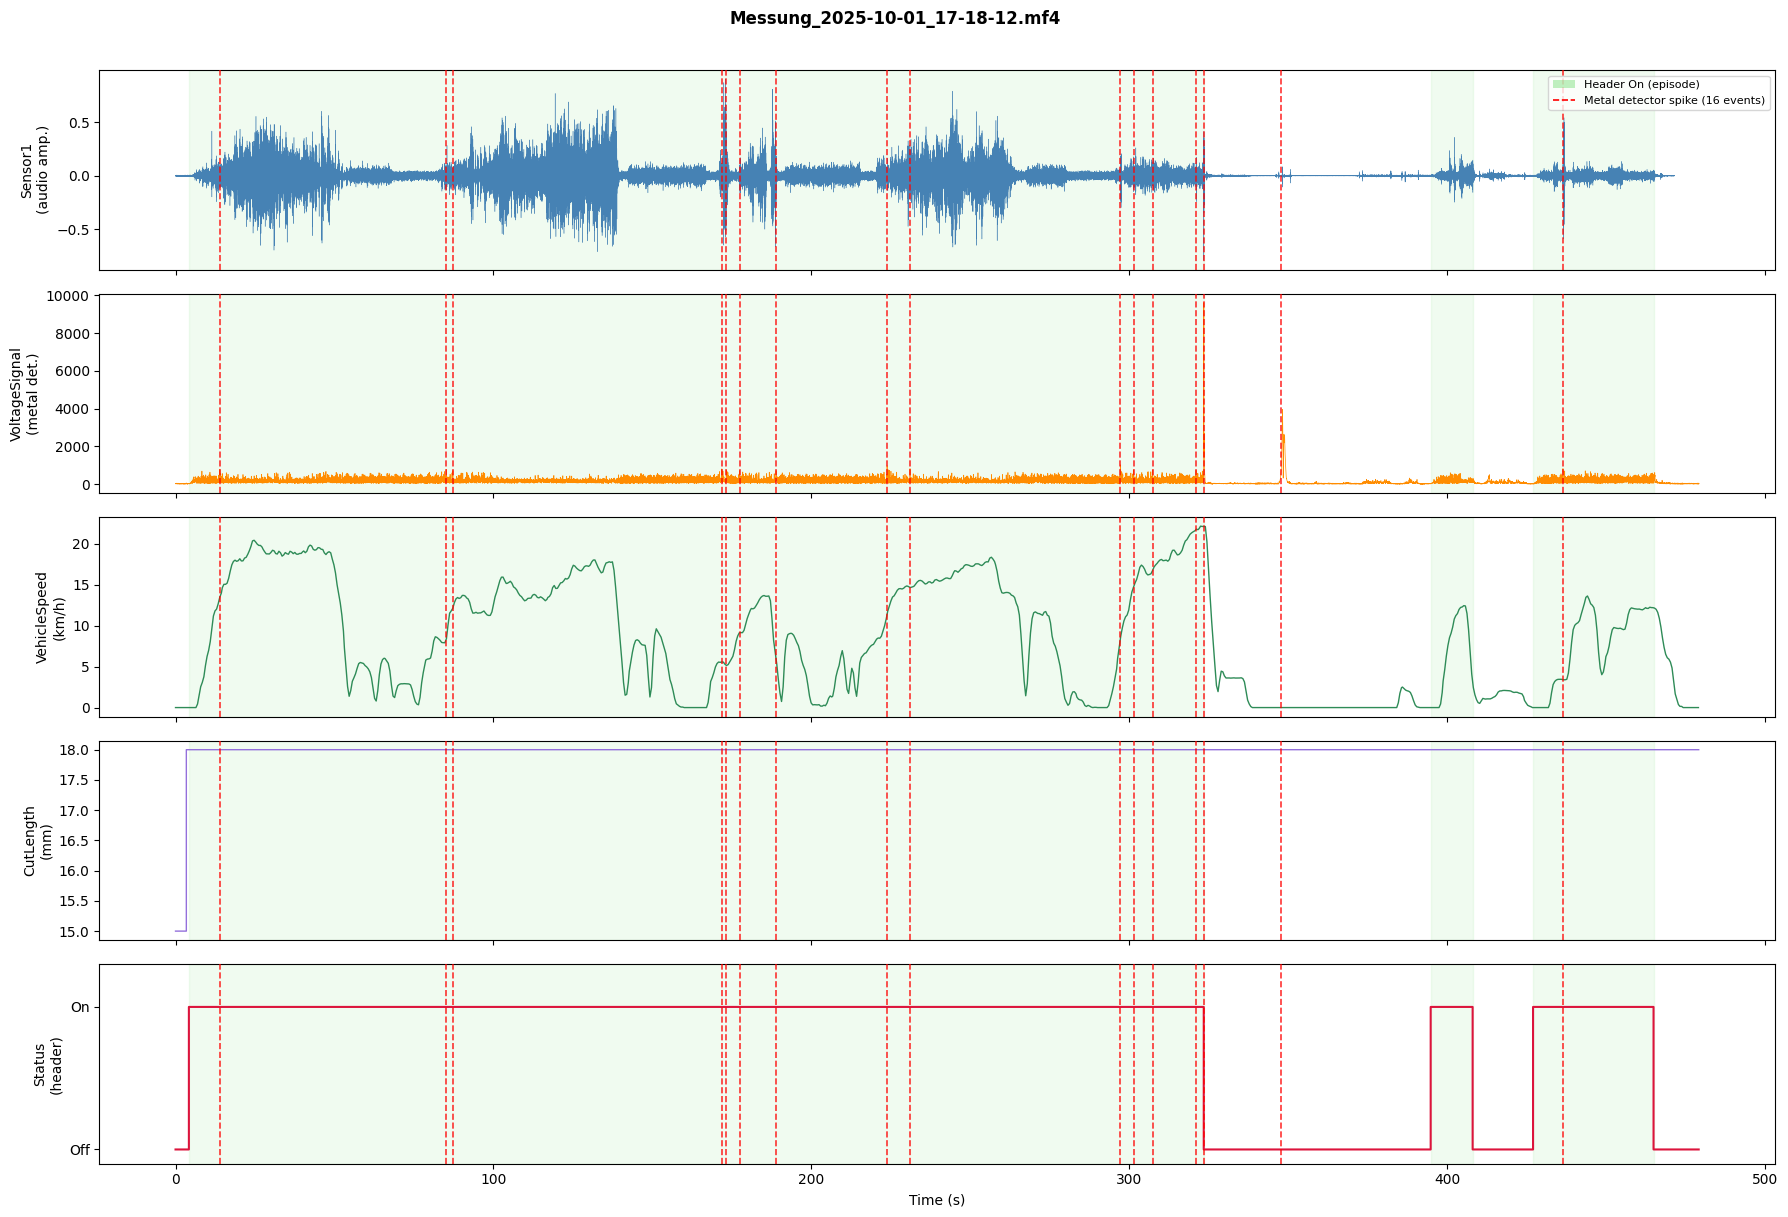

Episodes and stone events in Messung_2025-10-01_17-18-12.mf4:
  Episode 1  [4.2s → 323.4s]  duration=319.2s  → STONE at +9.73s into episode  (header shut down at 323.4s)
  Episode 2  [394.8s → 408.0s]  duration=13.2s  → no spike
  Episode 3  [427.0s → 464.9s]  duration=37.9s  → STONE at +9.39s into episode  (header shut down at 464.9s)



In [3]:
def plot_all_channels(path):
    ch = load_all_channels(path)
    spike_times = get_stone_spike_times(ch["VoltageSignal"])
    status_binary = status_to_binary(ch["Status"])
    
    audio  = ch["Sensor1"]
    volt   = ch["VoltageSignal"]
    speed  = ch["VehicleSpeed"]
    cut    = ch["CutLength"]
    status = ch["Status"]
    
    fig, axes = plt.subplots(5, 1, figsize=(18, 12), sharex=True)
    fig.suptitle(f"{path.name}", fontsize=12, fontweight='bold', y=1.01)
    
    # --- Row 1: Sensor1 (audio) ---
    step = 100  # downsample for plotting
    axes[0].plot(audio.timestamps[::step], audio.samples[::step],
                 lw=0.3, color='steelblue')
    axes[0].set_ylabel("Sensor1\n(audio amp.)")
    
    # --- Row 2: VoltageSignal ---
    axes[1].plot(volt.timestamps, volt.samples, lw=0.5, color='darkorange')
    axes[1].set_ylabel("VoltageSignal\n(metal det.)")
    
    # --- Row 3: VehicleSpeed ---
    axes[2].plot(speed.timestamps, speed.samples, lw=1.0, color='seagreen')
    axes[2].set_ylabel("VehicleSpeed\n(km/h)")
    
    # --- Row 4: CutLength ---
    axes[3].step(cut.timestamps, cut.samples, lw=1.0, color='mediumpurple', where='post')
    axes[3].set_ylabel("CutLength\n(mm)")
    
    # --- Row 5: Status (converted to 0/1) ---
    axes[4].step(status.timestamps, status_binary, lw=1.5, color='crimson', where='post')
    axes[4].set_yticks([0, 1])
    axes[4].set_yticklabels(['Off', 'On'])
    axes[4].set_ylabel("Status\n(header)")
    axes[4].set_ylim(-0.1, 1.3)
    axes[4].set_xlabel("Time (s)")
    
    # Shade header-On periods and mark stone spikes on ALL rows
    # Find On periods from status
    s_str = status.samples.astype(str)
    s_t   = status.timestamps
    changes = np.where(s_str[:-1] != s_str[1:])[0]
    on_periods = []
    for i in changes:
        if s_str[i] == 'Off' and s_str[i+1] == 'On':
            start = s_t[i+1]
            future_off = [s_t[j+1] for j in changes if j > i and s_str[j] == 'On' and s_str[j+1] == 'Off']
            end = future_off[0] if future_off else s_t[-1]
            on_periods.append((start, end))
    
    for ax in axes:
        for (on_start, on_end) in on_periods:
            ax.axvspan(on_start, on_end, alpha=0.07, color='limegreen', zorder=0)
        for st in spike_times:
            ax.axvline(st, color='red', lw=1.2, linestyle='--', alpha=0.8, zorder=5)
    
    # Legend
    legend_handles = [
        mpatches.Patch(facecolor='limegreen', alpha=0.3, label='Header On (episode)'),
        plt.Line2D([0], [0], color='red', linestyle='--', lw=1.2, label=f'Metal detector spike ({len(spike_times)} events)'),
    ]
    axes[0].legend(handles=legend_handles, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print episode + spike summary below the plot
    print(f"Episodes and stone events in {path.name}:")
    for i, (on_s, on_e) in enumerate(on_periods):
        spikes_in_ep = spike_times[(spike_times >= on_s) & (spike_times <= on_e)]
        if len(spikes_in_ep) > 0:
            advance = spikes_in_ep[0] - on_s
            print(f"  Episode {i+1}  [{on_s:.1f}s → {on_e:.1f}s]  duration={on_e-on_s:.1f}s  "
                  f"→ STONE at +{advance:.2f}s into episode  (header shut down at {on_e:.1f}s)")
        else:
            print(f"  Episode {i+1}  [{on_s:.1f}s → {on_e:.1f}s]  duration={on_e-on_s:.1f}s  → no spike")
    print()

for f in MF4_FILES:
    plot_all_channels(f)

## Zoom: Status transition around a stone event

Tight zoom showing the exact sequence:
1. Header is On (Status = 1)
2. VoltageSignal spikes (stone detected by metal detector)
3. Status drops to 0 (header shuts down)

The gap between step 2 and step 3 is the metal detector's own reaction time.

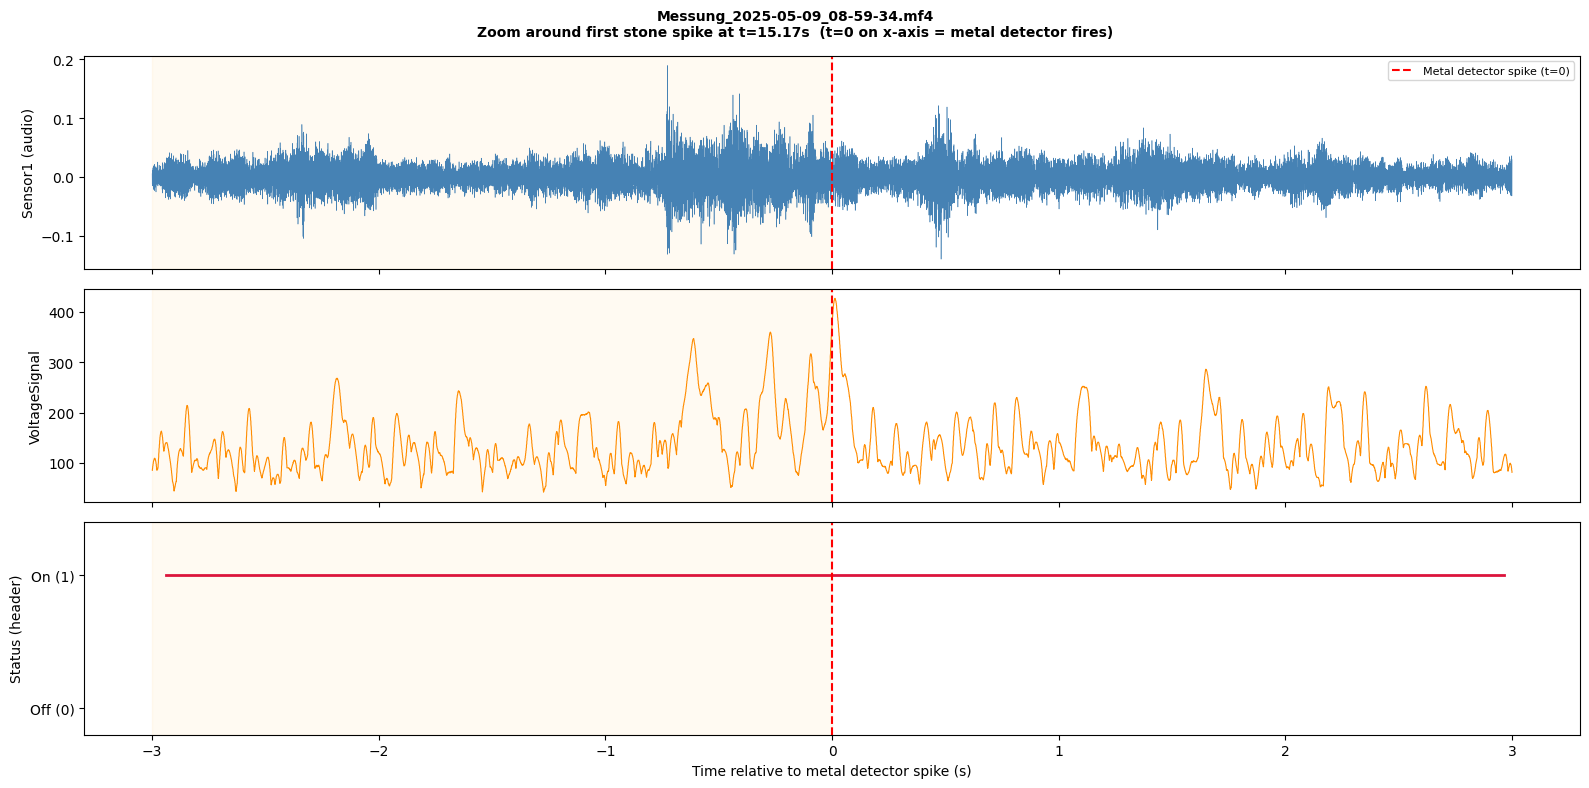

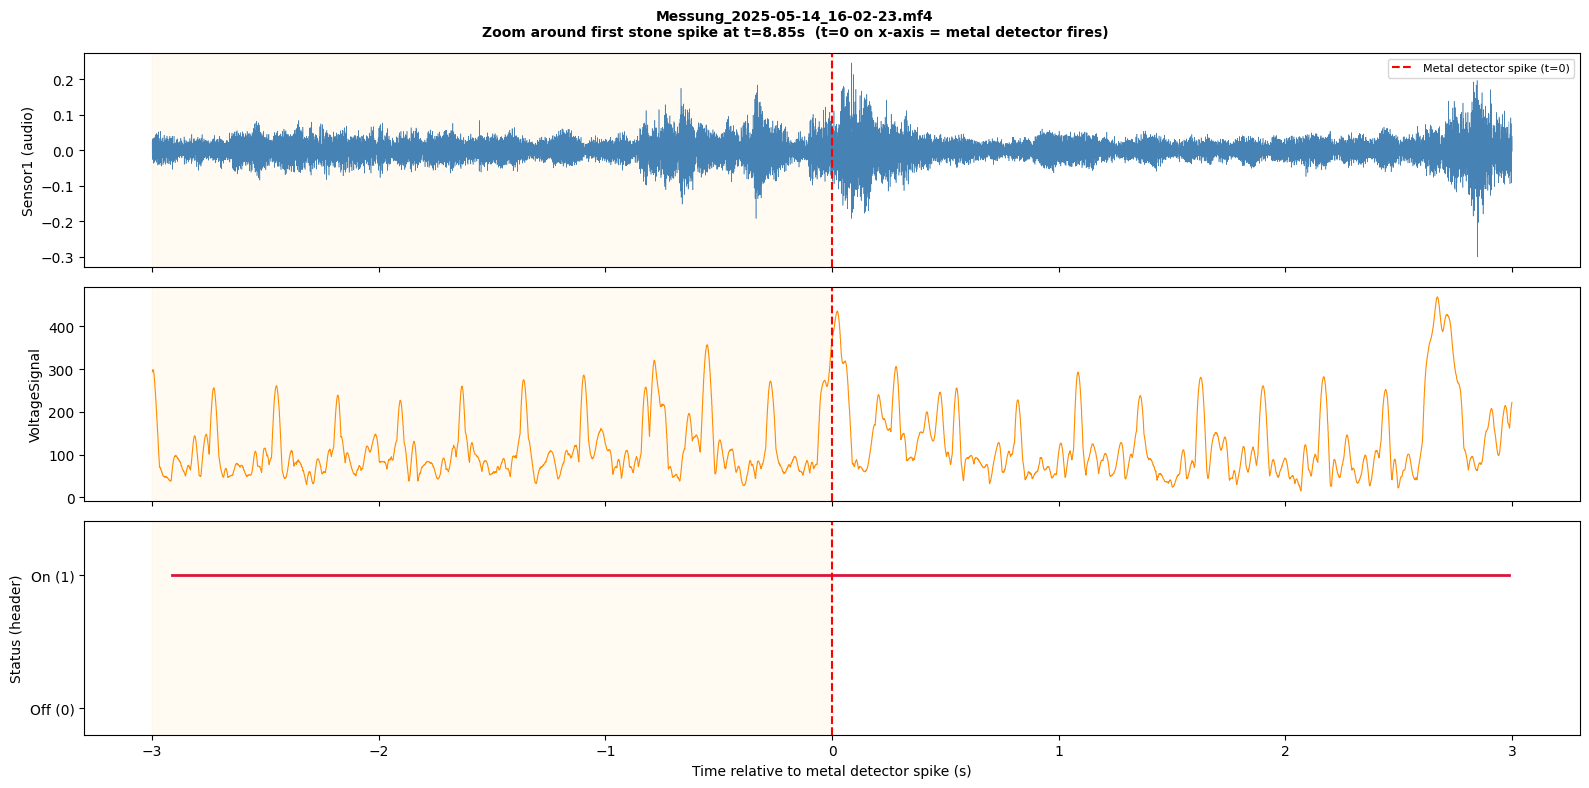

Messung_2025-05-20_16-30-26.mf4: metal detector fires → header shuts off 0.004s later


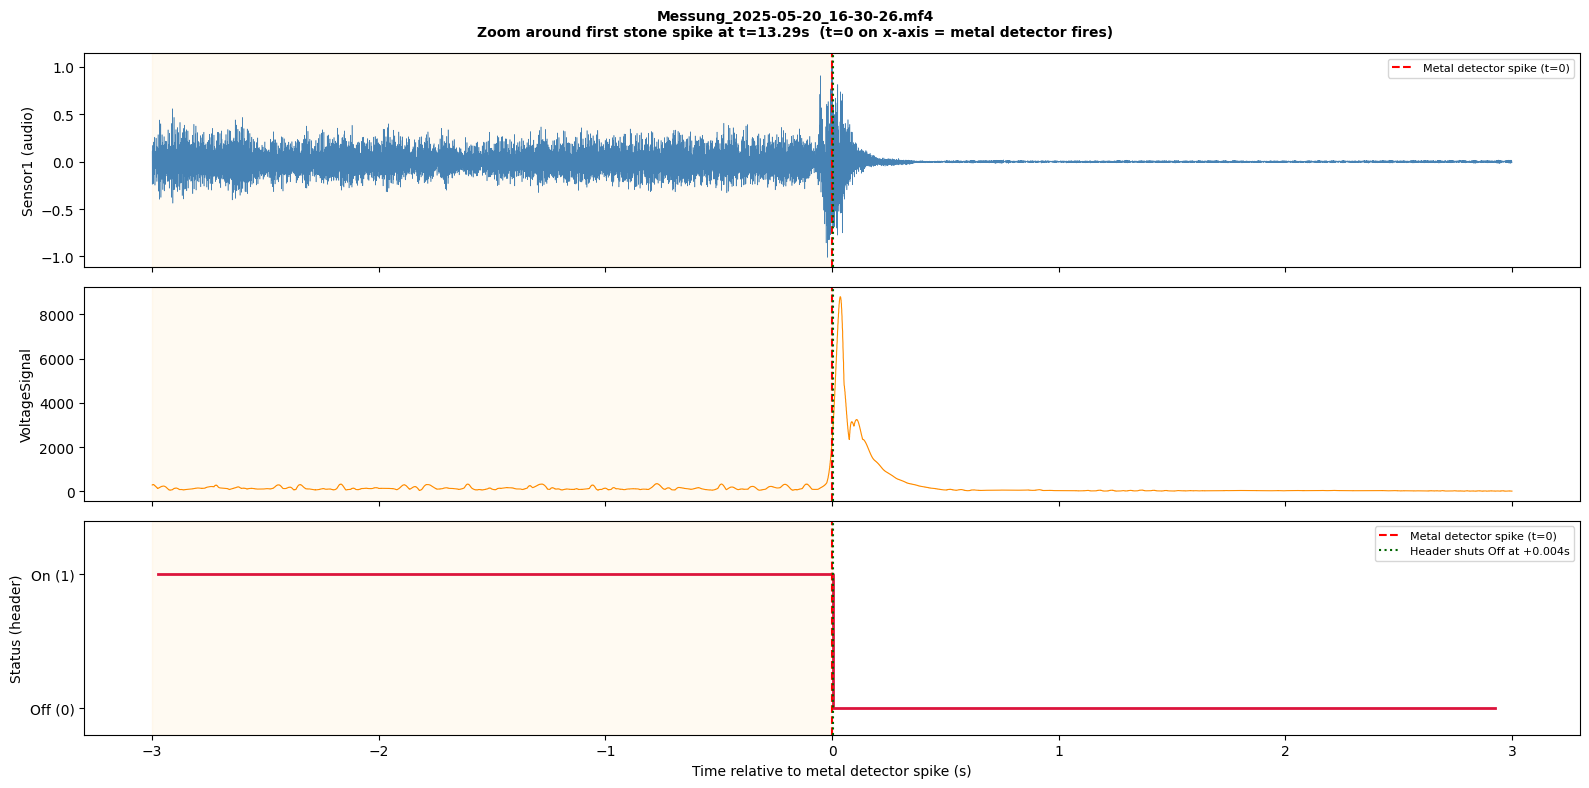

Messung_2025-10-01_09-42-16.mf4: metal detector fires → header shuts off 2.338s later


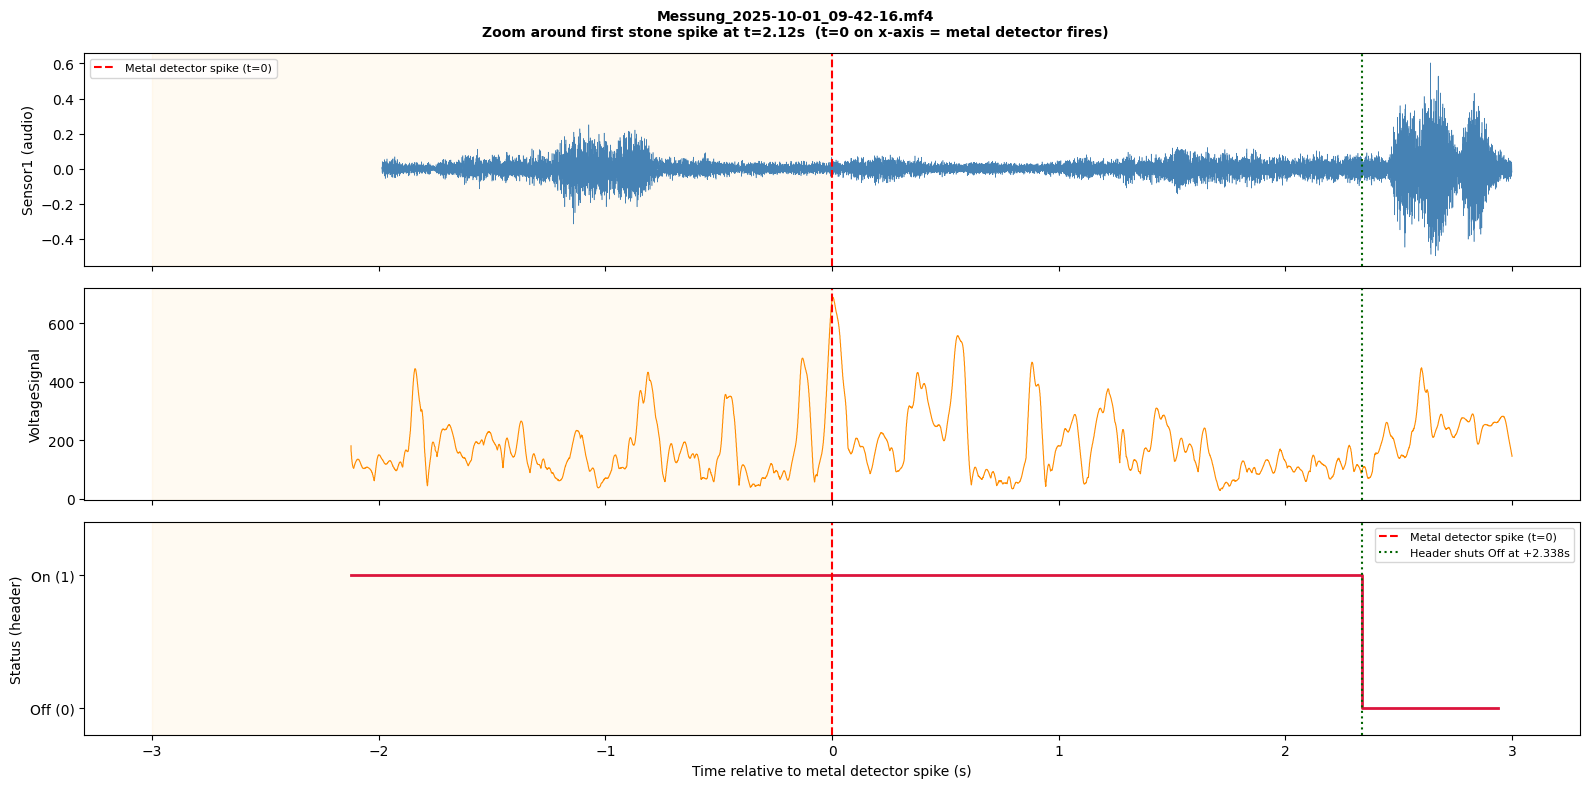

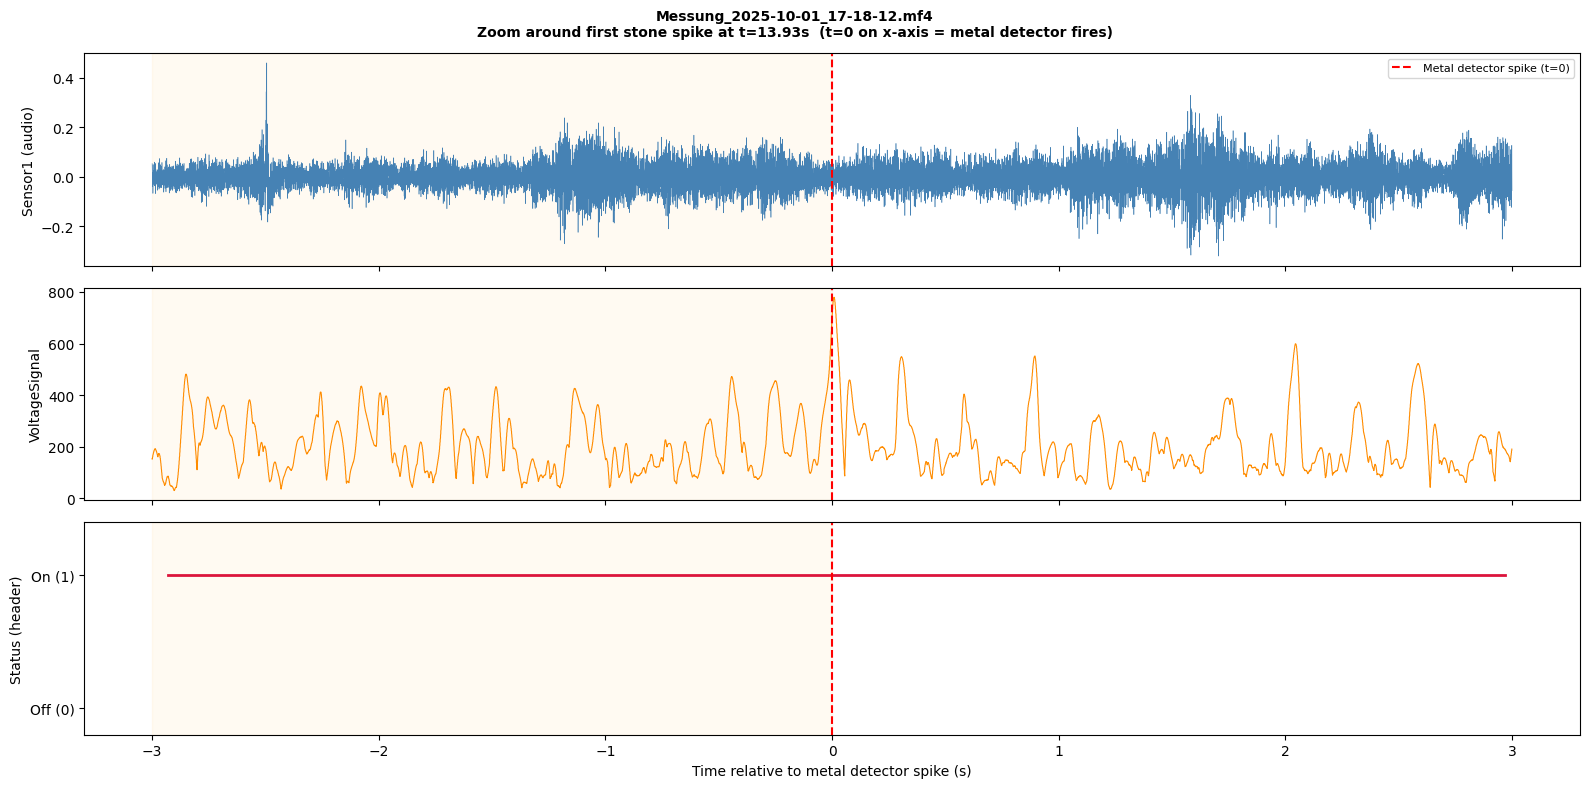

In [4]:
def plot_stone_shutdown_zoom(path, window_before=3.0, window_after=3.0):
    ch = load_all_channels(path)
    spike_times = get_stone_spike_times(ch["VoltageSignal"])
    
    if len(spike_times) == 0:
        print(f"{path.name}: no stone spikes detected, skipping zoom.")
        return
    
    # Use the first (largest context) spike event
    spike_t = spike_times[0]
    t_lo = spike_t - window_before
    t_hi = spike_t + window_after
    
    audio  = ch["Sensor1"]
    volt   = ch["VoltageSignal"]
    status = ch["Status"]
    status_bin = status_to_binary(status)
    
    def crop(channel, lo, hi, binary=False):
        mask = (channel.timestamps >= lo) & (channel.timestamps <= hi)
        t = channel.timestamps[mask] - spike_t  # relative to spike
        s = binary[mask] if binary is not False else channel.samples[mask]
        return t, s
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(
        f"{path.name}\nZoom around first stone spike at t={spike_t:.2f}s  "
        f"(t=0 on x-axis = metal detector fires)",
        fontsize=10, fontweight='bold'
    )
    
    # Audio
    step = 10
    mask_a = (audio.timestamps >= t_lo) & (audio.timestamps <= t_hi)
    a_t = audio.timestamps[mask_a] - spike_t
    a_s = audio.samples[mask_a]
    axes[0].plot(a_t[::step], a_s[::step], lw=0.4, color='steelblue')
    axes[0].set_ylabel("Sensor1 (audio)")
    
    # Voltage
    t_v, s_v = crop(volt, t_lo, t_hi)
    axes[1].plot(t_v, s_v, lw=0.8, color='darkorange')
    axes[1].set_ylabel("VoltageSignal")
    
    # Status as 0/1
    mask_s = (status.timestamps >= t_lo) & (status.timestamps <= t_hi)
    s_t_rel = status.timestamps[mask_s] - spike_t
    s_bin   = status_bin[mask_s]
    axes[2].step(s_t_rel, s_bin, lw=2.0, color='crimson', where='post')
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Off (0)', 'On (1)'])
    axes[2].set_ylabel("Status (header)")
    axes[2].set_ylim(-0.2, 1.4)
    axes[2].set_xlabel("Time relative to metal detector spike (s)")
    
    for ax in axes:
        ax.axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector spike (t=0)')
        ax.axvspan(-window_before, 0, alpha=0.05, color='orange')
    
    axes[0].legend(fontsize=8)
    
    # Annotate: find when status drops to Off after spike
    shutdown_candidates = s_t_rel[(s_bin == 0) & (s_t_rel > 0)]
    if len(shutdown_candidates) > 0:
        shutdown_rel = shutdown_candidates[0]
        for ax in axes:
            ax.axvline(shutdown_rel, color='darkgreen', lw=1.5, linestyle=':',
                       label=f'Header shuts Off at +{shutdown_rel:.3f}s')
        axes[2].legend(fontsize=8)
        print(f"{path.name}: metal detector fires → header shuts off {shutdown_rel:.3f}s later")
    
    plt.tight_layout()
    plt.show()

for f in MF4_FILES:
    plot_stone_shutdown_zoom(f)